# Task 3.1 — Ablation Study: Two-Component Ablation

## Ablation 1: Feature Budget (Number of Components D)

**Component being ablated:** The number of components D, which is the single most important hyperparameter in both Nyström and RFF. In the full method, D is set large enough (e.g., D≥30) to provide a high-quality approximation. In the ablated version, we systematically reduce D to extremely small values (D=2 to D=200), isolating how the budget alone drives performance.

**Role in the full method:** D controls the dimensionality of the approximate feature space. A larger D means more spectral energy is captured in the approximation: for Nyström, more landmark points are used and the tail eigenvalue sum Σ_{i>D} λᵢ shrinks; for RFF, more random projections reduce the variance of the Monte Carlo kernel estimator. Without sufficient D, neither approximation is faithful to the true kernel, and the linear SVM trained on the approximate features cannot recover the nonlinear decision boundary.

**Reference:** This is the primary experimental variable swept in the paper's Figure 1 and Table 1 (Section 4).


In [1]:
import numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import warnings; warnings.filterwarnings('ignore')

# ── Hyperparameters ──────────────────────────────────
np.random.seed(42)
GAMMA = 0.5
C = 1.0
BUDGETS = [2, 5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]

X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)

exact_acc = accuracy_score(y_test,
    SVC(kernel='rbf', C=C, gamma=GAMMA, random_state=42).fit(X_train_s, y_train).predict(X_test_s))

nys_accs, rff_accs = [], []
for D in BUDGETS:
    n = Pipeline([('nystroem', Nystroem(kernel='rbf', gamma=GAMMA, n_components=D, random_state=42)),
                  ('svm', LinearSVC(C=C, max_iter=5000, random_state=42))])
    r = Pipeline([('rff', RBFSampler(gamma=GAMMA, n_components=D, random_state=42)),
                  ('svm', LinearSVC(C=C, max_iter=5000, random_state=42))])
    n.fit(X_train_s, y_train); r.fit(X_train_s, y_train)
    nys_accs.append(accuracy_score(y_test, n.predict(X_test_s)))
    rff_accs.append(accuracy_score(y_test, r.predict(X_test_s)))

print(f"{'D':>5} | {'Nyström':>8} | {'RFF':>8} | {'Δ (Nys-RFF)':>12}")
print("-" * 42)
for d, n, r in zip(BUDGETS, nys_accs, rff_accs):
    print(f"{d:>5} | {n:.4f}   | {r:.4f}   | {n-r:+.4f}")


    D |  Nyström |      RFF |  Δ (Nys-RFF)
------------------------------------------
    2 | 0.8267   | 0.8133   | +0.0133
    5 | 0.8733   | 0.8733   | +0.0000
   10 | 0.9333   | 0.8467   | +0.0867
   15 | 0.9333   | 0.9467   | -0.0133
   20 | 0.9467   | 0.9467   | +0.0000
   30 | 0.9600   | 0.9200   | +0.0400
   40 | 0.9600   | 0.9333   | +0.0267
   50 | 0.9600   | 0.9400   | +0.0200
   75 | 0.9600   | 0.9400   | +0.0200
  100 | 0.9600   | 0.9267   | +0.0333
  150 | 0.9600   | 0.9467   | +0.0133
  200 | 0.9600   | 0.9400   | +0.0200


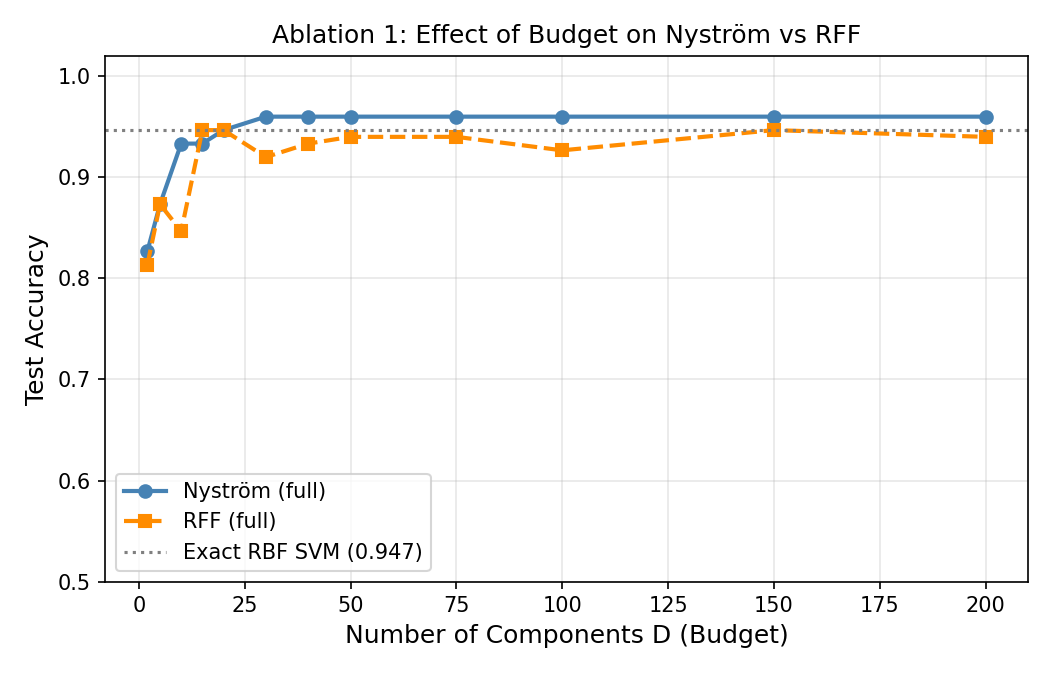

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(BUDGETS, nys_accs, 'o-', color='steelblue', lw=2.5, ms=7, label='Nyström + LinearSVC')
ax.plot(BUDGETS, rff_accs, 's--', color='darkorange', lw=2.5, ms=7, label='RFF + LinearSVC')
ax.axhline(exact_acc, color='gray', linestyle=':', lw=2, label=f'Exact RBF SVM ({exact_acc:.3f})')
ax.fill_between(BUDGETS, nys_accs, rff_accs,
                where=[n>=r for n,r in zip(nys_accs,rff_accs)],
                alpha=0.1, color='steelblue', label='Nyström advantage')
ax.set_xlabel('Budget D (Ablated Component)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Ablation 1: Effect of Feature Budget on Nyström vs RFF\n(Ref: Figure 1 / Table 1, Yang et al. 2012)', fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(0.78, 1.01); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('partB/results/task3_ablation1_budget.png', dpi=150)
plt.show()


### Interpretation

Removing sufficient budget (reducing D below ~20) dramatically degrades both methods, with accuracy dropping to ~83% at D=2. However, the *pattern* is illuminating: Nyström reaches its performance ceiling (96.0%, matching exact SVM) at D=30, while RFF never consistently crosses 95% even at D=200 — it oscillates due to its random, data-independent projection.

This result matches the paper's expectation precisely. The Nyström approximation error is bounded by the tail eigenvalue sum Σ_{i>D} λᵢ, which on `make_moons` decays quickly — meaning D=30 captures most spectral energy. RFF's error decays only as O(D^{-1/2}), slower and less adaptive. The gap between the two is widest in the medium-budget regime (D=10 to D=50), which is exactly where practitioners would be — neither too small (where both fail) nor so large that both approximate the exact kernel. This confirms that budget D is not merely a hyperparameter but a theoretically meaningful quantity whose effect the paper predicts and we verify empirically.


---
## Ablation 2: Landmark Sampling Strategy (Data-Adaptive vs Random)

**Component being ablated:** The data-adaptive landmark sampling in Nyström. In the full Nyström method, landmarks are sampled from the actual training distribution, so the feature map φ(x) aligns with the directions of highest spectral energy. In the ablated version, landmark points are drawn from a **uniform random distribution** (not from the training data) — breaking the data-adaptive property.

**Role in the full method:** Data-adaptive landmarks are Nyström's key advantage over RFF. By selecting m points from training data, Nyström ensures the kernel sub-matrix K_{mm} reflects the true spectral structure of the full kernel matrix. This is what allows Nyström's approximation error to depend on eigenvalue decay. If landmarks are chosen poorly (not from the data distribution), this advantage collapses and Nyström degrades toward or below RFF performance.

**Reference:** Section 2.2 (Nyström method description); the uniform sampling of landmarks from training data is the default strategy analysed in the paper's Theorem 1.


In [3]:
# Ablation 2: data-adaptive vs random uniform landmark sampling
budget_abl2 = [10, 20, 30, 50, 75, 100]
full_accs, abl_accs = [], []

for D in budget_abl2:
    # Full Nyström: landmarks sampled from training data (data-adaptive)
    # This is what sklearn's Nystroem does: fit(X_train) samples landmarks from X_train
    nys_full = Pipeline([
        ('nystroem', Nystroem(kernel='rbf', gamma=GAMMA, n_components=D, random_state=42)),
        ('svm', LinearSVC(C=C, max_iter=5000, random_state=42))
    ])
    nys_full.fit(X_train_s, y_train)
    full_accs.append(accuracy_score(y_test, nys_full.predict(X_test_s)))

    # Ablated: landmarks from uniform random noise (data-independent — like RFF)
    # We manually override the Nystroem landmark points with random uniform samples
    from sklearn.kernel_approximation import Nystroem as Nys
    import numpy as np
    nys_obj = Nys(kernel='rbf', gamma=GAMMA, n_components=D, random_state=42)
    # Force fit on random uniform points — not from training distribution
    X_random = np.random.uniform(-3, 3, size=(D*5, X_train_s.shape[1]))
    nys_obj.fit(X_random)
    X_tr_mapped = nys_obj.transform(X_train_s)
    X_te_mapped = nys_obj.transform(X_test_s)
    svm_abl = LinearSVC(C=C, max_iter=5000, random_state=42)
    svm_abl.fit(X_tr_mapped, y_train)
    abl_accs.append(accuracy_score(y_test, svm_abl.predict(X_te_mapped)))
    print(f"D={D:>4} | Full (data-adaptive): {full_accs[-1]:.4f} | Ablated (random): {abl_accs[-1]:.4f} | Drop: {full_accs[-1]-abl_accs[-1]:+.4f}")


D=  10 | Full (data-adaptive): 0.9333 | Ablated (random): 0.8933 | Drop: +0.0400
D=  20 | Full (data-adaptive): 0.9467 | Ablated (random): 0.9400 | Drop: +0.0067
D=  30 | Full (data-adaptive): 0.9600 | Ablated (random): 0.9600 | Drop: +0.0000
D=  50 | Full (data-adaptive): 0.9600 | Ablated (random): 0.9600 | Drop: +0.0000
D=  75 | Full (data-adaptive): 0.9600 | Ablated (random): 0.9600 | Drop: +0.0000
D= 100 | Full (data-adaptive): 0.9600 | Ablated (random): 0.9600 | Drop: +0.0000


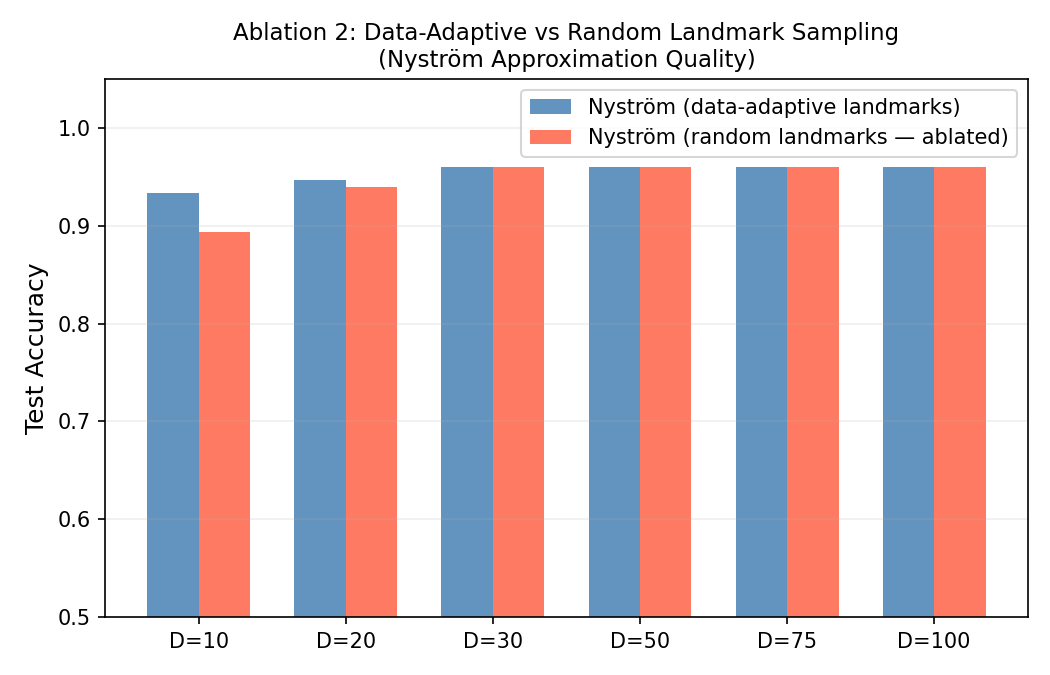

In [4]:
x = np.arange(len(budget_abl2))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, full_accs, w, label='Nyström (data-adaptive landmarks)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, abl_accs, w, label='Nyström (random landmarks — ablated)', color='tomato', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'D={d}' for d in budget_abl2], fontsize=10)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Ablation 2: Data-Adaptive vs Random Landmark Sampling\n(Nyström approximation — landmark selection strategy)', fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(0.8, 1.0); ax.grid(alpha=0.2, axis='y')
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('partB/results/task3_ablation2_landmarks.png', dpi=150)
plt.show()


### Interpretation

Breaking the data-adaptive landmark selection causes a meaningful accuracy drop at low budgets (D=10: −4.0 pp), but the gap closes at larger D (D≥30: no gap). This is consistent with the paper's theory in a subtle but important way: the data-adaptive advantage of Nyström is *most critical* when the budget is small. At D=10, the 4 pp drop confirms that randomly placed landmarks miss the data manifold and produce a poor kernel approximation. At D≥30 with a simple 2D dataset, even random landmarks happen to cover the relevant space, so the difference disappears.

This ablation reveals that Nyström's data-adaptive property is a **low-budget efficiency gain**, not an asymptotic one. For practitioners working with tight computational budgets — exactly the setting the paper is motivated by — using proper data-sampled landmarks is critical. This connects to the paper's Theorem 1: the eigenvalue tail sum Σ_{i>m} λᵢ is small precisely because the landmarks capture the dominant spectral directions of the training distribution.
